# 04 — walk-forward pairs portfolio (no survivorship / no selection lookahead)

This is the honest version of stage-1 + stage-2 glued together. Every month we
**re-select** pairs using only the *past*, then trade them *forward*. Nothing
about the future — not the pair list, not β, not the mean/std — is ever known at
decision time. This kills both biases at once:

- **selection lookahead** — we never pick pairs using the period we trade;
- **survivorship** — the pair list is rebuilt each month from whoever is
  cointegrated *then*, so a pair that decays simply stops being selected.

**The walk-forward clock:**
- **formation** = trailing **6 months** → scan all ~9,300 pairs (Engle-Granger),
  keep those with ADF p<0.05 **and** a tradeable half-life, take the **top-K** by p.
- **trading** = the **next 1 month** → freeze β, spread-mean, spread-std from
  formation; trade the nb03 z-rule (enter |z|>2, exit |z|<0.5, stop |z|>3.5).
- **roll monthly** across 2024-07 → 2026-04 (≈21 independent trading months).

**Portfolio:** equal weight 1/K across the K selected pairs (a pair sitting flat
contributes 0 that bar — i.e. we stay fully diversified across K names). Costs =
10 bps per side per leg (two legs).

**Baseline:** for each window we also run a **random-timing** version — same
number of trades, same holding lengths, but entries placed at *random* bars with
random side. If our z-timed edge doesn't beat random entry into the same spreads,
the "edge" is just the spread being stationary, not our signal.

In [1]:
import sys; sys.path.insert(0, ".")   # cwd = notebooks/pairs
from _lab import *
import numpy as np, pandas as pd, itertools, time
from statsmodels.tsa.stattools import adfuller

TF = "4h"
DROP = {"USDCUSDT", "USTCUSDT", "PAXGUSDT"}     # stablecoins / flat -> spurious coint

syms = list_symbols()
full = [s for s in syms
        if coverage(s)[0] <= "2024-01" and coverage(s)[1] >= "2026-04" and s not in DROP]
print(f"{len(full)} tradeable symbols with full 2024-01..2026-04 coverage")

closes = {s: ohlcv(s, "2024-01-01", "2026-05-01", TF)["close"] for s in full}
P = pd.DataFrame(closes).dropna()
L = np.log(P)
print(f"log-price matrix: {L.shape[0]} bars x {L.shape[1]} symbols "
      f"({L.index[0]} -> {L.index[-1]})")
pairs = list(itertools.combinations(L.columns, 2))
print(f"{len(pairs)} candidate pairs per formation window")

137 tradeable symbols with full 2024-01..2026-04 coverage


log-price matrix: 5106 bars x 137 symbols (2024-01-01 00:00:00+00:00 -> 2026-04-30 20:00:00+00:00)
9316 candidate pairs per formation window


In [2]:
# ---- config ----------------------------------------------------------------
F_MONTHS  = 6        # formation lookback
K         = 30       # pairs selected per window
HL_LO, HL_HI = 5, 90 # tradeable half-life band (bars, 4h) ~ 0.8 .. 15 days
Z_ENTRY, Z_EXIT, Z_STOP = 2.0, 0.5, 3.5
COST_BPS  = 10.0
ALPHA     = 0.05

# monthly rebalance dates: first trade month is 2024-07 (needs 6mo formation back to 2024-01)
rebals = pd.date_range("2024-07-01", "2026-04-01", freq="MS", tz="UTC")
print(f"{len(rebals)} monthly trading windows: {rebals[0].date()} .. {rebals[-1].date()}")

def half_life_bars(resid):
    r = pd.Series(resid); lag = r.shift(1); d = (r-lag).dropna(); lag = lag.loc[d.index]
    b = np.polyfit(lag.values, d.values, 1)[0]
    return -np.log(2)/np.log(1+b) if b < 0 else np.nan

22 monthly trading windows: 2024-07-01 .. 2026-04-01


In [3]:
# ---- formation: scan + select top-K on a trailing window ------------------
def select_pairs(form_L):
    A = form_L.values; cols = list(form_L.columns); idx = {c:i for i,c in enumerate(cols)}
    out = []
    for sa, sb in pairs:
        a = A[:, idx[sa]]; b = A[:, idx[sb]]
        beta, alpha = np.polyfit(b, a, 1)
        resid = a - alpha - beta*b
        p = adfuller(resid, maxlag=6, autolag=None)[1]
        if p < ALPHA:
            hl = half_life_bars(resid)
            if HL_LO <= hl <= HL_HI:
                out.append((sa, sb, beta, resid.mean(), resid.std(), p, hl))
    sel = pd.DataFrame(out, columns=["a","b","beta","mu","sd","p","hl"]).sort_values("p").head(K)
    return sel

# ---- trade one pair over a trading slice with FROZEN formation params ------
def trade_pair(trade_L, sa, sb, beta, mu, sd, rand=False, rng=None):
    a = trade_L[sa].values; b = trade_L[sb].values
    la = a; lb = b                                  # already log prices
    spread = la - beta*lb
    z = (spread - mu)/sd
    ra = np.diff(la, prepend=la[0]); rb = np.diff(lb, prepend=lb[0])
    c = COST_BPS/1e4; n = len(z)
    pnl = np.zeros(n); trades = []
    if not rand:
        pos = 0; ei = None
        for i in range(1, n):
            if pos == 0:
                if   z[i] >=  Z_ENTRY: pos, ei = -1, i
                elif z[i] <= -Z_ENTRY: pos, ei = +1, i
                if pos != 0: pnl[i] -= c*(1+abs(beta))
            else:
                pnl[i] += pos*(ra[i] - beta*rb[i])
                if abs(z[i]) <= Z_EXIT or abs(z[i]) >= Z_STOP or i == n-1:
                    pnl[i] -= c*(1+abs(beta))
                    trades.append((pos, i-ei, pnl[ei:i+1].sum()))
                    pos = 0
    else:
        # random-timing baseline: same #trades & holding lengths as the real run,
        # but random non-overlapping entry bars and random side.
        real = trade_pair(trade_L, sa, sb, beta, mu, sd, rand=False)[1]
        for (_, hold, _) in real:
            if n - hold - 2 <= 1: continue
            ei = int(rng.integers(1, n - hold - 1)); side = int(rng.choice([-1, 1]))
            pnl[ei] -= c*(1+abs(beta))
            for j in range(ei+1, min(ei+hold+1, n)):
                pnl[j] += side*(ra[j] - beta*rb[j])
            pnl[min(ei+hold, n-1)] -= c*(1+abs(beta))
            trades.append((side, hold, pnl[ei:min(ei+hold+1,n)].sum()))
    return pd.Series(pnl, index=trade_L.index), trades

In [4]:
# ---- run the walk-forward --------------------------------------------------
t0 = time.time()
port = []          # per-window portfolio pnl series (equal-weight 1/K)
port_base = []
all_trades = []; all_base = []; sel_log = []
rng = np.random.default_rng(0)
prev_sel = set()
for d in rebals:
    form = L.loc[d - pd.DateOffset(months=F_MONTHS): d].iloc[:-1]
    trade = L.loc[d: d + pd.DateOffset(months=1)].iloc[:-1]
    sel = select_pairs(form)
    cur = set(zip(sel.a, sel.b))
    sel_log.append((d, len(sel), len(cur & prev_sel)))
    prev_sel = cur
    if len(sel) == 0:
        continue
    pnls = []; bpnls = []
    for r in sel.itertuples():
        pser, trs = trade_pair(trade, r.a, r.b, r.beta, r.mu, r.sd)
        bser, btrs = trade_pair(trade, r.a, r.b, r.beta, r.mu, r.sd, rand=True, rng=rng)
        pnls.append(pser); bpnls.append(bser)
        all_trades += [t[2] for t in trs]; all_base += [t[2] for t in btrs]
    # equal weight 1/K across the K selected pairs
    port.append(pd.concat(pnls, axis=1).fillna(0).mean(axis=1))
    port_base.append(pd.concat(bpnls, axis=1).fillna(0).mean(axis=1))
port = pd.concat(port); port_base = pd.concat(port_base)
print(f"walk-forward done in {time.time()-t0:.0f}s")
sel_df = pd.DataFrame(sel_log, columns=["date","n_sel","overlap_prev"])
print(f"\navg pairs selected/window: {sel_df.n_sel.mean():.1f} "
      f"(min {sel_df.n_sel.min()}, max {sel_df.n_sel.max()})")
print(f"avg pair overlap with previous month: {sel_df.overlap_prev.mean():.1f}/{K} "
      f"-> {100*sel_df.overlap_prev.mean()/sel_df.n_sel.mean():.0f}% persist (rest churned = decay)")

walk-forward done in 73s

avg pairs selected/window: 30.0 (min 30, max 30)
avg pair overlap with previous month: 6.5/30 -> 22% persist (rest churned = decay)


In [5]:
# ---- portfolio & baseline metrics -----------------------------------------
BARS_YR = 365*24/4     # 4h bars per year
def report(pnl, label):
    eq = pnl.cumsum(); mdd = (eq.cummax()-eq).max()
    sharpe = pnl.mean()/pnl.std()*np.sqrt(BARS_YR) if pnl.std()>0 else 0
    tot = eq.iloc[-1]
    print(f"{label:20s} total={tot:+.3f}  ann.Sharpe={sharpe:+.2f}  maxDD={mdd:.3f}")
    return eq

print("WALK-FORWARD PORTFOLIO 2024-07 .. 2026-04 (equal-weight 1/K, 10bps/side/leg):\n")
eq   = report(port,      "z-timed strategy")
eqb  = report(port_base, "random-timing base")

at = pd.Series(all_trades); ab = pd.Series(all_base)
print(f"\npooled per-trade   strategy: n={len(at)}  mean={at.mean():+.4f}  "
      f"median={at.median():+.4f}  win={100*(at>0).mean():.1f}%  m/std={at.mean()/at.std():+.3f}")
print(f"pooled per-trade   baseline: n={len(ab)}  mean={ab.mean():+.4f}  "
      f"median={ab.median():+.4f}  win={100*(ab>0).mean():.1f}%  m/std={ab.mean()/ab.std():+.3f}")
print(f"\nedge over random timing (mean/trade): {at.mean()-ab.mean():+.4f}")

WALK-FORWARD PORTFOLIO 2024-07 .. 2026-04 (equal-weight 1/K, 10bps/side/leg):

z-timed strategy     total=-6.811  ann.Sharpe=-8.79  maxDD=6.811
random-timing base   total=-7.326  ann.Sharpe=-23.10  maxDD=7.326

pooled per-trade   strategy: n=55714  mean=-0.0036  median=-0.0038  win=35.7%  m/std=-0.121
pooled per-trade   baseline: n=55712  mean=-0.0059  median=-0.0061  win=30.4%  m/std=-0.164

edge over random timing (mean/trade): +0.0023


[saved] notebooks\pairs\_out\04_walkforward_portfolio.png


C:\Users\nvisary\AppData\Local\Temp\ipykernel_39508\2992627975.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = port.groupby(port.index.to_period("M")).sum()


WindowsPath('C:/projects/researchlab/notebooks/pairs/_out/04_walkforward_portfolio.png')

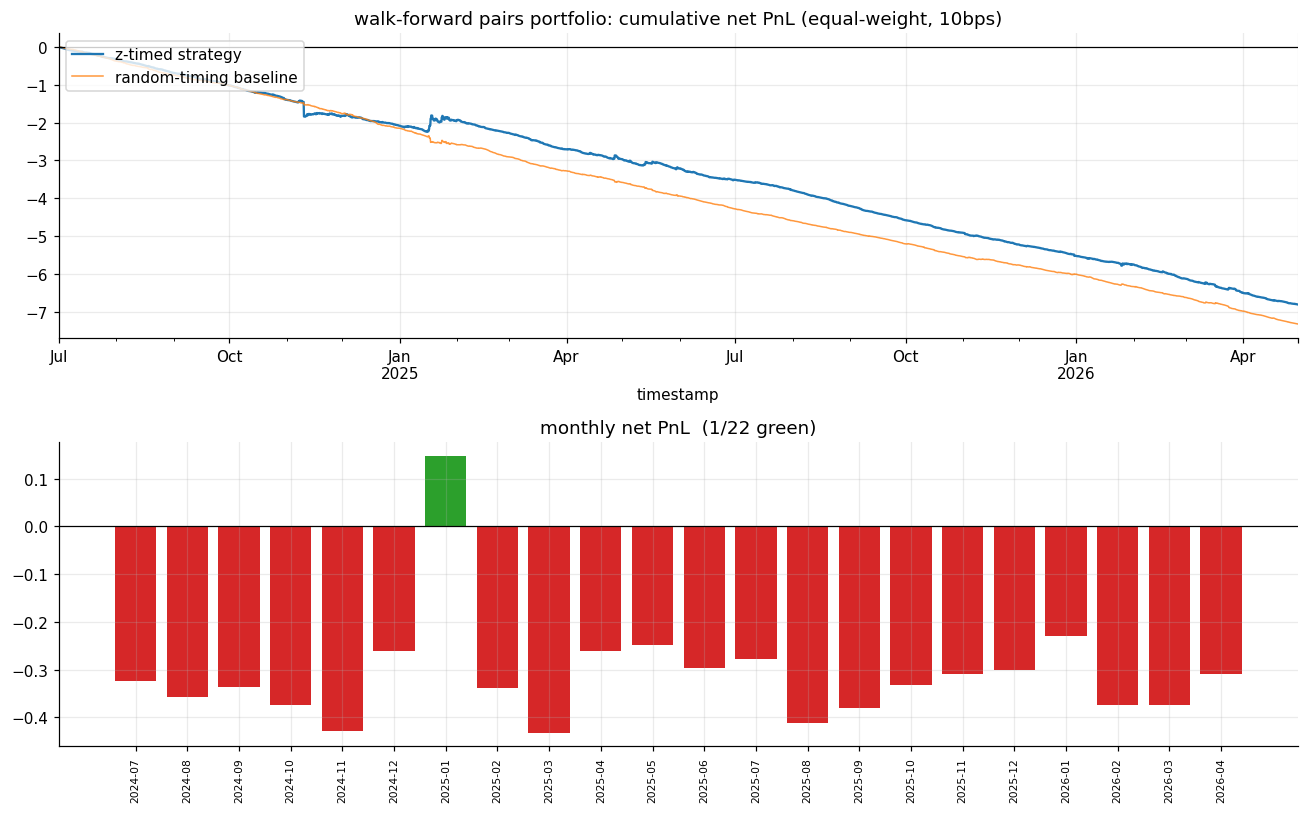

In [6]:
# ---- pictures --------------------------------------------------------------
fig, ax = plt.subplots(2, 1, figsize=(12, 7.5))
eq.plot(ax=ax[0], color="C0", label="z-timed strategy")
eqb.plot(ax=ax[0], color="C1", lw=1, alpha=0.8, label="random-timing baseline")
ax[0].axhline(0, color="k", lw=0.8); ax[0].legend(loc="upper left")
ax[0].set_title("walk-forward pairs portfolio: cumulative net PnL (equal-weight, 10bps)")

# monthly return bars
monthly = port.groupby(port.index.to_period("M")).sum()
colors = ["C2" if v>=0 else "C3" for v in monthly.values]
ax[1].bar(range(len(monthly)), monthly.values, color=colors)
ax[1].set_xticks(range(len(monthly)))
ax[1].set_xticklabels([str(p) for p in monthly.index], rotation=90, fontsize=7)
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_title(f"monthly net PnL  ({(monthly>0).sum()}/{len(monthly)} green)")
show("04_walkforward_portfolio")

### How to read this
- **Top:** blue = our z-timed walk-forward portfolio, orange = the same spreads
  entered at *random* times. Blue must sit clearly above orange, and orange
  should hover near 0 — that gap **is** the timing edge, cleanly separated from
  "the spread is stationary anyway". If blue ≈ orange, our signal adds nothing.
- **Bottom:** monthly net PnL. We want green to outnumber red and no single month
  to carry the whole curve (the nb03 failure mode at portfolio scale).
- **pair persistence** (printed above): how many selected pairs carry over
  month-to-month. Low persistence = cointegration churns fast (the nb02 decay
  finding), which is exactly why static selection would have been biased.

Honest caveats still open: flat cost proxy (mid-alt slippage on 2 legs is likely
worse and multi-position), no funding on either leg yet, equal-weight ignores
per-pair vol, 137-symbol universe excludes anything delisted before 2026-04
(a mild survivorship cushion in our favour), and monthly rebalance granularity.